## Классификация претензий BNP Paribas Cardif

Применяем четыре метода классификации:
1. Логистическая регрессия (бейзлайн)
2. SVM
3. Random Forest
4. CatBoost (градиентный бустинг)

**Метрики:** LogLoss, Precision, Recall, PR-AUC

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import skew

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    log_loss, precision_score, recall_score,
    average_precision_score, precision_recall_curve,
    classification_report
)
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42

### Загрузка данных

In [2]:
train_path = '../data/bnp-paribas-cardif-claims-management/train.csv'

df = pd.read_csv(train_path)
print(f'Shape: {df.shape}')
print(f'Target distribution:')
print(df['target'].value_counts(normalize=True))

Shape: (114321, 133)
Target distribution:
target
1    0.761199
0    0.238801
Name: proportion, dtype: float64


In [3]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in ['ID', 'target']:
    if col in numerical_cols:
        numerical_cols.remove(col)

print(f'Numerical features: {len(numerical_cols)}')
print(f'Categorical features: {len(categorical_cols)}')

Numerical features: 112
Categorical features: 19


In [4]:
X = df.drop(['ID', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target distribution:')
print(y_train.value_counts(normalize=True))

Train: (91456, 131), Test: (22865, 131)
Train target distribution:
target
1    0.761197
0    0.238803
Name: proportion, dtype: float64


### Предобработка

Из EDA:
- 112 числовых и 19 категориальных признаков
- Значительные пропуски во многих признаках
- Числовые признаки на разных масштабах

**Логистическая регрессия и SVM** требуют:
- Перевод числовых признаков с малым числом уникальных значений в категориальные (v38, v62, v72, v129)
- Отбрасывание признаков с ненормальным распределением
- Заполнение пропусков (медиана для числовых, "missing" для категориальных)
- Label Encoding категориальных признаков
- Стандартизацию числовых признаков

**CatBoost** работает с пропусками и категориальными признаками нативно.

In [5]:
# Числовые признаки с малым числом уникальных значений -> категориальные
nunique = df[numerical_cols].nunique().sort_values()
low_cardinality_num = nunique[nunique <= 20].index.tolist()
print('Числовые признаки с <= 20 уникальных значений (переводим в категориальные):')
for col in low_cardinality_num:
    print(f'  {col}: {nunique[col]} уникальных значений')

skewness = df[numerical_cols].apply(lambda x: skew(x.dropna()))
high_skew_cols = skewness[skewness.abs() > 3].index.tolist()
print(f'\nПризнаки с |skewness| > 3 (отбрасываем для линейных моделей): {len(high_skew_cols)} шт')
print(high_skew_cols)

Числовые признаки с <= 20 уникальных значений (переводим в категориальные):
  v62: 8 уникальных значений
  v129: 10 уникальных значений
  v38: 12 уникальных значений
  v72: 13 уникальных значений

Признаки с |skewness| > 3 (отбрасываем для линейных моделей): 21 шт
['v8', 'v18', 'v19', 'v23', 'v25', 'v37', 'v38', 'v39', 'v46', 'v54', 'v63', 'v72', 'v86', 'v89', 'v92', 'v95', 'v104', 'v105', 'v124', 'v126', 'v128']


In [6]:
def preprocess_for_linear(X_train, X_test, numerical_cols, categorical_cols,
                          low_cardinality_num, high_skew_cols):
    """Предобработка для линейных моделей (LogReg, SVM)."""
    X_tr = X_train.copy()
    X_te = X_test.copy()

    # 1. Переводим числовые с малым числом уникальных значений в категориальные
    cat_cols_extended = categorical_cols + low_cardinality_num
    num_cols_adjusted = [c for c in numerical_cols if c not in low_cardinality_num]

    for col in low_cardinality_num:
        X_tr[col] = X_tr[col].astype(str)
        X_te[col] = X_te[col].astype(str)

    # 2. Отбрасываем признаки с ненормальным распределением
    drop_cols = [c for c in high_skew_cols if c not in low_cardinality_num]
    X_tr = X_tr.drop(columns=drop_cols)
    X_te = X_te.drop(columns=drop_cols)
    num_cols_adjusted = [c for c in num_cols_adjusted if c not in drop_cols]

    print(f'Отброшено {len(drop_cols)} признаков с высокой асимметрией')
    print(f'Перевод {len(low_cardinality_num)} числовых признаков в категориальные')
    print(f'Итого: {len(num_cols_adjusted)} числовых, {len(cat_cols_extended)} категориальных')

    # 3. Категориальные: заполняем 'missing', затем LabelEncoding
    label_encoders = {}
    for col in cat_cols_extended:
        X_tr[col] = X_tr[col].fillna('missing').astype(str)
        X_te[col] = X_te[col].fillna('missing').astype(str)

        le = LabelEncoder()
        le.fit(pd.concat([X_tr[col], X_te[col]]))
        X_tr[col] = le.transform(X_tr[col])
        X_te[col] = le.transform(X_te[col])
        label_encoders[col] = le

    # 4. Числовые: заполняем медианой
    imputer = SimpleImputer(strategy='median')
    X_tr[num_cols_adjusted] = imputer.fit_transform(X_tr[num_cols_adjusted])
    X_te[num_cols_adjusted] = imputer.transform(X_te[num_cols_adjusted])

    # 5. Стандартизация всех признаков
    scaler = StandardScaler()
    X_tr_scaled = pd.DataFrame(
        scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index
    )
    X_te_scaled = pd.DataFrame(
        scaler.transform(X_te), columns=X_te.columns, index=X_te.index
    )

    return X_tr_scaled, X_te_scaled


X_train_lin, X_test_lin = preprocess_for_linear(
    X_train, X_test, numerical_cols, categorical_cols,
    low_cardinality_num, high_skew_cols
)
print(f'\nLinear-preprocessed train: {X_train_lin.shape}')
print(f'Missing values in train: {X_train_lin.isnull().sum().sum()}')

Отброшено 19 признаков с высокой асимметрией
Перевод 4 числовых признаков в категориальные
Итого: 89 числовых, 23 категориальных

Linear-preprocessed train: (91456, 112)
Missing values in train: 0


In [7]:
def evaluate_model(name, y_true, y_pred_proba, threshold=0.5):
    y_pred = (y_pred_proba >= threshold).astype(int)

    ll = log_loss(y_true, y_pred_proba)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    pr_auc = average_precision_score(y_true, y_pred_proba)

    print(f'=== {name} ===')
    print(f'LogLoss:   {ll:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall:    {rec:.4f}')
    print(f'PR-AUC:    {pr_auc:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=['Slow', 'Fast']))

    return {'model': name, 'LogLoss': ll, 'Precision': prec, 'Recall': rec, 'PR-AUC': pr_auc}

---
## 1. Логистическая регрессия (бейзлайн)

In [8]:
logreg = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    C=1.0
)
logreg.fit(X_train_lin, y_train)

y_proba_logreg = logreg.predict_proba(X_test_lin)[:, 1]
results_logreg = evaluate_model('Logistic Regression', y_test, y_proba_logreg)

=== Logistic Regression ===
LogLoss:   0.4955
Precision: 0.7750
Recall:    0.9786
PR-AUC:    0.8838

              precision    recall  f1-score   support

        Slow       0.58      0.09      0.16      5460
        Fast       0.77      0.98      0.86     17405

    accuracy                           0.77     22865
   macro avg       0.68      0.54      0.51     22865
weighted avg       0.73      0.77      0.70     22865



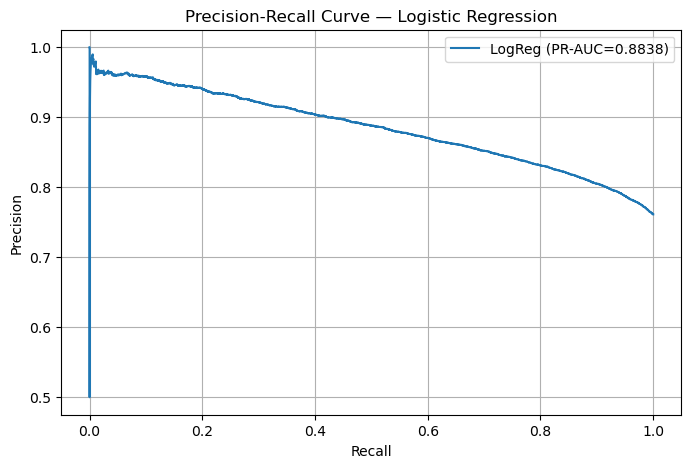

При пороге 0.9: Precision=0.9335, Recall=0.2338


In [9]:
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_test, y_proba_logreg)

plt.figure(figsize=(8, 5))
plt.plot(recall_lr, precision_lr, label=f'LogReg (PR-AUC={results_logreg["PR-AUC"]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Logistic Regression')
plt.legend()
plt.grid(True)
plt.show()

idx_90 = np.argmin(np.abs(thresholds_lr - 0.9))
print(f'При пороге 0.9: Precision={precision_lr[idx_90]:.4f}, Recall={recall_lr[idx_90]:.4f}')

---
## 2. SVM (LinearSVC)

In [10]:
base_svm = LinearSVC(
    max_iter=2000,
    random_state=RANDOM_STATE,
    C=1.0
)

svm_calibrated = CalibratedClassifierCV(base_svm, cv=3, method='sigmoid')
svm_calibrated.fit(X_train_lin, y_train)

y_proba_svm = svm_calibrated.predict_proba(X_test_lin)[:, 1]
results_svm = evaluate_model('SVM (LinearSVC)', y_test, y_proba_svm)

=== SVM (LinearSVC) ===
LogLoss:   0.4962
Precision: 0.7752
Recall:    0.9778
PR-AUC:    0.8825

              precision    recall  f1-score   support

        Slow       0.58      0.10      0.17      5460
        Fast       0.78      0.98      0.86     17405

    accuracy                           0.77     22865
   macro avg       0.68      0.54      0.51     22865
weighted avg       0.73      0.77      0.70     22865



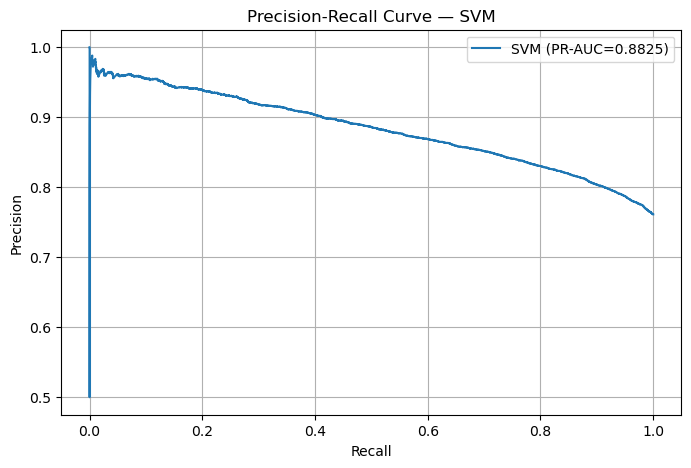

При пороге 0.9: Precision=0.9348, Recall=0.2176


In [11]:
precision_svm, recall_svm, thresholds_svm = precision_recall_curve(y_test, y_proba_svm)

plt.figure(figsize=(8, 5))
plt.plot(recall_svm, precision_svm, label=f'SVM (PR-AUC={results_svm["PR-AUC"]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — SVM')
plt.legend()
plt.grid(True)
plt.show()

idx_90 = np.argmin(np.abs(thresholds_svm - 0.9))
print(f'При пороге 0.9: Precision={precision_svm[idx_90]:.4f}, Recall={recall_svm[idx_90]:.4f}')

---
## 3. Random Forest

Деревья не требуют стандартизации и устойчивы к асимметрии распределений — используем все признаки с минимальной предобработкой (импутация + LabelEncoding).

In [12]:
# Предобработка для Random Forest
def preprocess_for_trees(X_train, X_test, numerical_cols, categorical_cols):
    X_tr = X_train.copy()
    X_te = X_test.copy()

    for col in categorical_cols:
        X_tr[col] = X_tr[col].fillna('missing').astype(str)
        X_te[col] = X_te[col].fillna('missing').astype(str)
        le = LabelEncoder()
        le.fit(pd.concat([X_tr[col], X_te[col]]))
        X_tr[col] = le.transform(X_tr[col])
        X_te[col] = le.transform(X_te[col])

    imputer = SimpleImputer(strategy='median')
    X_tr[numerical_cols] = imputer.fit_transform(X_tr[numerical_cols])
    X_te[numerical_cols] = imputer.transform(X_te[numerical_cols])
    return X_tr, X_te

X_train_rf, X_test_rf = preprocess_for_trees(X_train, X_test, numerical_cols, categorical_cols)
print(f'Tree-preprocessed train: {X_train_rf.shape}')
print(f'Missing values: {X_train_rf.isnull().sum().sum()}')

Tree-preprocessed train: (91456, 131)
Missing values: 0


In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train)

y_proba_rf = rf_model.predict_proba(X_test_rf)[:, 1]
results_rf = evaluate_model('Random Forest', y_test, y_proba_rf)

=== Random Forest ===
LogLoss:   0.4804
Precision: 0.7837
Recall:    0.9780
PR-AUC:    0.8963

              precision    recall  f1-score   support

        Slow       0.67      0.14      0.23      5460
        Fast       0.78      0.98      0.87     17405

    accuracy                           0.78     22865
   macro avg       0.72      0.56      0.55     22865
weighted avg       0.76      0.78      0.72     22865



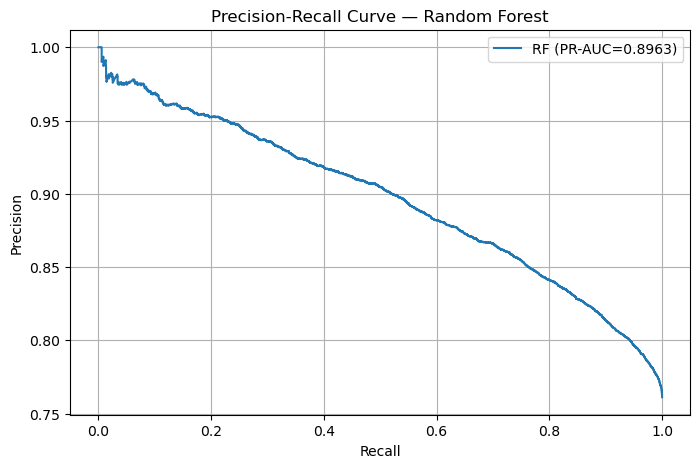

При пороге 0.9: Precision=0.9549, Recall=0.1716


In [14]:
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 5))
plt.plot(recall_rf, precision_rf, label=f'RF (PR-AUC={results_rf["PR-AUC"]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve \u2014 Random Forest')
plt.legend()
plt.grid(True)
plt.show()

idx_90 = np.argmin(np.abs(thresholds_rf - 0.9))
print(f'При пороге 0.9: Precision={precision_rf[idx_90]:.4f}, Recall={recall_rf[idx_90]:.4f}')

---
## 4. CatBoost (градиентный бустинг)

CatBoost нативно работает с пропусками и категориальными признаками — отдельная предобработка не требуется.

In [15]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

for col in categorical_cols:
    X_train_cb[col] = X_train_cb[col].fillna('missing').astype(str)
    X_test_cb[col] = X_test_cb[col].fillna('missing').astype(str)

cat_indices = [X_train_cb.columns.get_loc(col) for col in categorical_cols]
print(f'Categorical feature indices: {cat_indices}')

Categorical feature indices: [2, 21, 23, 29, 30, 46, 51, 55, 65, 70, 73, 74, 78, 90, 106, 109, 111, 112, 124]


In [16]:
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='Logloss',
    random_seed=RANDOM_STATE,
    cat_features=cat_indices,
    verbose=100,
    early_stopping_rounds=50
)

catboost_model.fit(
    X_train_cb, y_train,
    eval_set=(X_test_cb, y_test),
    use_best_model=True
)

y_proba_cb = catboost_model.predict_proba(X_test_cb)[:, 1]
results_cb = evaluate_model('CatBoost', y_test, y_proba_cb)

0:	learn: 0.6705211	test: 0.6708360	best: 0.6708360 (0)	total: 114ms	remaining: 1m 53s
100:	learn: 0.4632922	test: 0.4658026	best: 0.4658026 (100)	total: 5.05s	remaining: 44.9s
200:	learn: 0.4537961	test: 0.4576673	best: 0.4576673 (200)	total: 9.8s	remaining: 39s
300:	learn: 0.4477190	test: 0.4541610	best: 0.4541610 (300)	total: 14.6s	remaining: 33.8s
400:	learn: 0.4427768	test: 0.4523788	best: 0.4523788 (400)	total: 19.2s	remaining: 28.7s
500:	learn: 0.4383529	test: 0.4512146	best: 0.4512028 (498)	total: 23.9s	remaining: 23.8s
600:	learn: 0.4343277	test: 0.4505579	best: 0.4505579 (600)	total: 28.5s	remaining: 18.9s
700:	learn: 0.4308001	test: 0.4501759	best: 0.4501719 (697)	total: 33.1s	remaining: 14.1s
800:	learn: 0.4271580	test: 0.4499500	best: 0.4499032 (798)	total: 37.6s	remaining: 9.34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4497305698
bestIteration = 831

Shrink model to first 832 iterations.
=== CatBoost ===
LogLoss:   0.4497
Precision: 0.8036
Recal

200:	learn: 0.4537961	test: 0.4576673	best: 0.4576673 (200)	total: 12.4s	remaining: 49.5s


300:	learn: 0.4477190	test: 0.4541610	best: 0.4541610 (300)	total: 19s	remaining: 44.1s


400:	learn: 0.4427768	test: 0.4523788	best: 0.4523788 (400)	total: 24.9s	remaining: 37.1s


500:	learn: 0.4383529	test: 0.4512146	best: 0.4512028 (498)	total: 30.9s	remaining: 30.8s


600:	learn: 0.4343277	test: 0.4505579	best: 0.4505579 (600)	total: 36.7s	remaining: 24.4s


700:	learn: 0.4308001	test: 0.4501759	best: 0.4501719 (697)	total: 42.5s	remaining: 18.1s


800:	learn: 0.4271580	test: 0.4499500	best: 0.4499032 (798)	total: 48.3s	remaining: 12s


Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.4497305698
bestIteration = 831

Shrink model to first 832 iterations.
=== CatBoost ===
LogLoss:   0.4497
Precision: 0.8036
Recall:    0.9611
PR-AUC:    0.9145

              precision    recall  f1-score   support

        Slow       0.67      0.25      0.37      5460
        Fast       0.80      0.96      0.88     17405

    accuracy                           0.79     22865
   macro avg       0.74      0.61      0.62     22865
weighted avg       0.77      0.79      0.75     22865



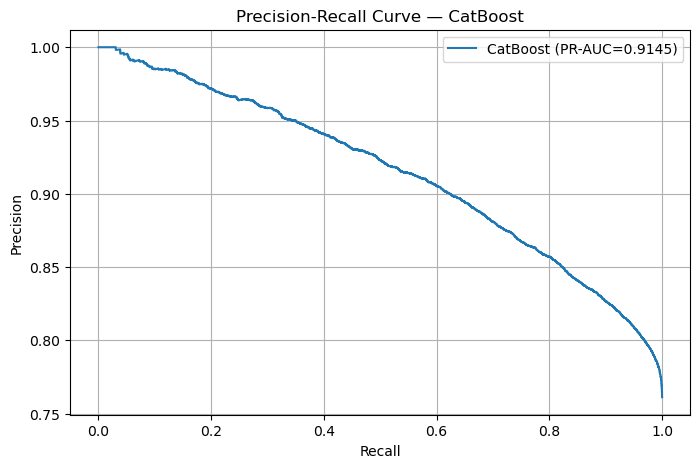

При пороге 0.9: Precision=0.9506, Recall=0.3364


In [17]:
precision_cb, recall_cb, thresholds_cb = precision_recall_curve(y_test, y_proba_cb)

plt.figure(figsize=(8, 5))
plt.plot(recall_cb, precision_cb, label=f'CatBoost (PR-AUC={results_cb["PR-AUC"]:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — CatBoost')
plt.legend()
plt.grid(True)
plt.show()

idx_90 = np.argmin(np.abs(thresholds_cb - 0.9))
print(f'При пороге 0.9: Precision={precision_cb[idx_90]:.4f}, Recall={recall_cb[idx_90]:.4f}')

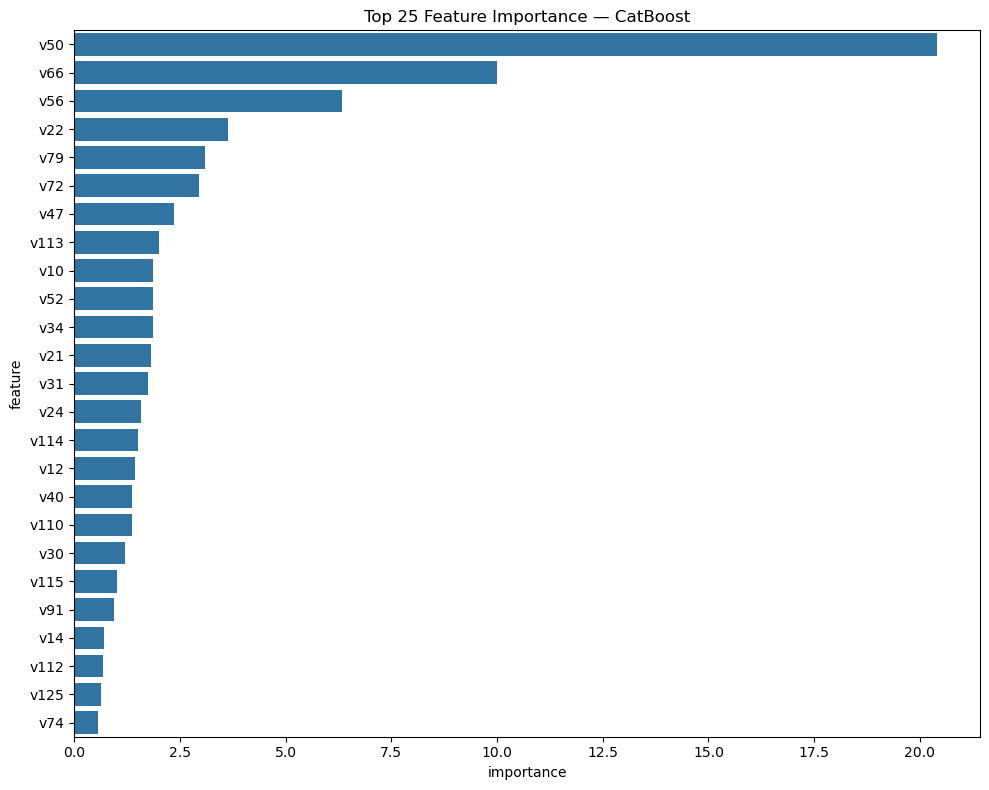

In [18]:
feature_imp = pd.DataFrame({
    'feature': X_train_cb.columns,
    'importance': catboost_model.get_feature_importance()
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_imp.head(25))
plt.title('Top 25 Feature Importance — CatBoost')
plt.tight_layout()
plt.show()

---
## Сравнение моделей

In [19]:
results_df = pd.DataFrame([results_logreg, results_svm, results_rf, results_cb])
results_df = results_df.set_index('model')
print(results_df.to_string())

                      LogLoss  Precision    Recall    PR-AUC
model                                                       
Logistic Regression  0.495453   0.774992  0.978569  0.883752
SVM (LinearSVC)      0.496245   0.775237  0.977765  0.882509
Random Forest        0.480396   0.783666  0.977995  0.896317
CatBoost             0.449731   0.803613  0.961103  0.914538


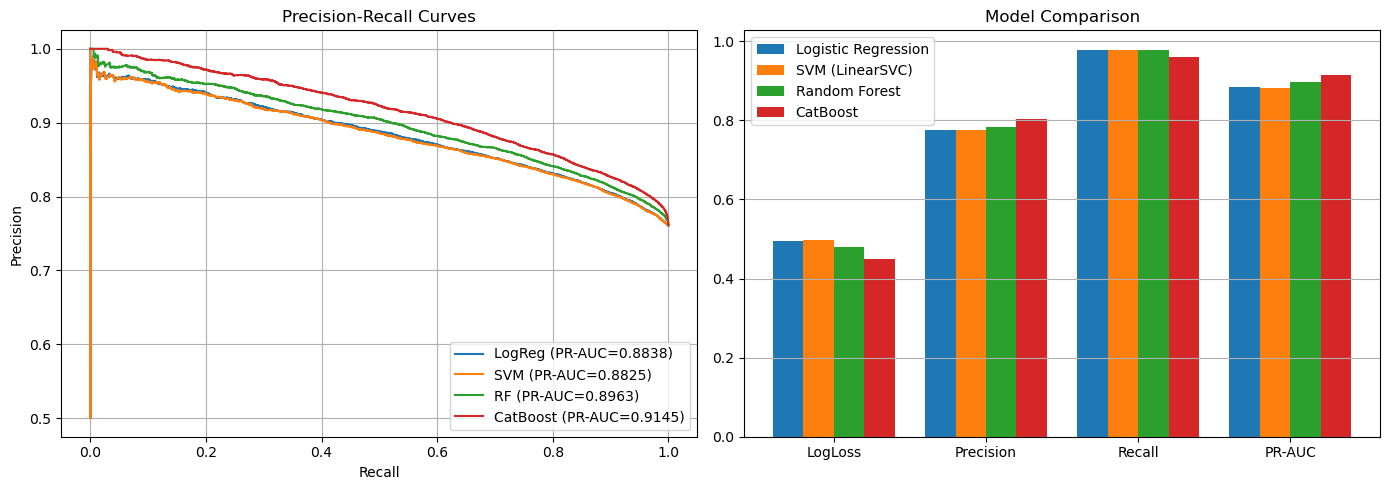

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(recall_lr, precision_lr, label=f'LogReg (PR-AUC={results_logreg["PR-AUC"]:.4f})')
axes[0].plot(recall_svm, precision_svm, label=f'SVM (PR-AUC={results_svm["PR-AUC"]:.4f})')
axes[0].plot(recall_rf, precision_rf, label=f'RF (PR-AUC={results_rf["PR-AUC"]:.4f})')
axes[0].plot(recall_cb, precision_cb, label=f'CatBoost (PR-AUC={results_cb["PR-AUC"]:.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curves')
axes[0].legend()
axes[0].grid(True)

metrics = ['LogLoss', 'Precision', 'Recall', 'PR-AUC']
x = np.arange(len(metrics))
width = 0.2

for i, (name, row) in enumerate(results_df.iterrows()):
    axes[1].bar(x + i * width, [row[m] for m in metrics], width, label=name)

axes[1].set_xticks(x + 1.5 * width)
axes[1].set_xticklabels(metrics)
axes[1].set_title('Model Comparison')
axes[1].legend()
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

### Выводы

- **Логистическая регрессия** — простой бейзлайн, работает быстро, но ограничен линейностью
- **SVM (LinearSVC)** — линейная модель с максимизацией отступа, сопоставима с логистической регрессией
- **Random Forest** — ансамбль деревьев, не требует масштабирования и устойчив к асимметрии, занимает промежуточное положение между линейными моделями и бустингом
- **CatBoost** — лучшие результаты за счёт нелинейности, нативной работы с пропусками и категориальными признаками

Для линейных моделей дополнительная предобработка убирает шум. Для деревьев и бустинга такая фильтрация не нужна.